# Tutorial 01 — Your First CT Scan

**What you will learn:**
- What a CT scan actually *is* (the data behind the picture)
- How 3D medical images are stored in NIfTI files
- How to load and display a CT in three anatomical planes
- What Hounsfield Units (HU) are and why they matter

**No GPU needed.** This notebook uses a pre-generated chest CT that is already in the `outputs/` folder.

---
> **Safety reminder:** All images are fully synthetic — generated by AI, not from any real patient.

## What is a CT scan?

A CT (Computed Tomography) scanner sends X-rays through the body from many different angles and reconstructs a 3D image from those measurements.

The result is a **3D grid of numbers**, where each number represents how much the tissue at that point absorbed X-rays. This number is called a **Hounsfield Unit (HU)**.

Key HU landmarks:
- **Air** = −1000 HU → appears **black**
- **Fat** ≈ −100 HU → appears **dark grey**
- **Water / fluid** ≈ 0 HU → appears **medium grey**
- **Soft tissue** ≈ +40 HU → appears **mid grey**
- **Bone** ≈ +700 HU → appears **bright white**

Unlike a photograph, every number in a CT has a fixed physical meaning. That is what makes CT so powerful for AI.

---

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# Find the project root regardless of where Jupyter was launched from
PROJECT_ROOT = Path().resolve()
for _ in range(6):
    if (PROJECT_ROOT / 'outputs').exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

print('Project root:', PROJECT_ROOT)
%matplotlib inline
plt.rcParams.update({'figure.facecolor': '#0d1117', 'axes.facecolor': '#0d1117',
                     'text.color': 'white', 'axes.labelcolor': '#aaa',
                     'xtick.color': '#aaa', 'ytick.color': '#aaa'})
print('Setup complete.')

Project root: /home/mluser1/Musti_MAISI_Project
Setup complete.


In [2]:
# ── Load the chest CT ─────────────────────────────────────────────────────
ct_path = PROJECT_ROOT / 'outputs/maisi2_showcase_ct_chest_cardio_lung/visuals/sample_001_seed71001/ct_seed71001_image.nii.gz'

img  = nib.load(str(ct_path))
data = img.get_fdata(dtype=np.float32)
sx, sy, sz = img.header.get_zooms()[:3]

print('═' * 50)
print(f'  File  : {ct_path.name}')
print(f'  Shape : {data.shape}   (X × Y × Z voxels)')
print(f'  Spacing: {sx:.2f} × {sy:.2f} × {sz:.2f} mm per voxel')
print(f'  FOV   : {data.shape[0]*sx:.0f} × {data.shape[1]*sy:.0f} × {data.shape[2]*sz:.0f} mm')
print(f'  HU range: [{data.min():.0f}, {data.max():.0f}]')
print(f'  Mean HU : {data.mean():.0f}')
print('═' * 50)

══════════════════════════════════════════════════
  File  : ct_seed71001_image.nii.gz
  Shape : (256, 256, 128)   (X × Y × Z voxels)
  Spacing: 1.50 × 1.50 × 2.00 mm per voxel
  FOV   : 384 × 384 × 256 mm
  HU range: [-1000, 1000]
  Mean HU : -560
══════════════════════════════════════════════════


### What does the shape tell us?

A shape of **(256, 256, 128)** means:
- 256 voxels in the X direction (left–right)
- 256 voxels in the Y direction (front–back)
- 128 voxels in the Z direction (head–feet)

With spacing **1.5 × 1.5 × 2.0 mm**, the physical volume covered is:
- 384 × 384 × 256 mm — roughly a chest-sized field of view.

The total number of voxels = **256 × 256 × 128 = 8,388,608** — over 8 million individual measurements.

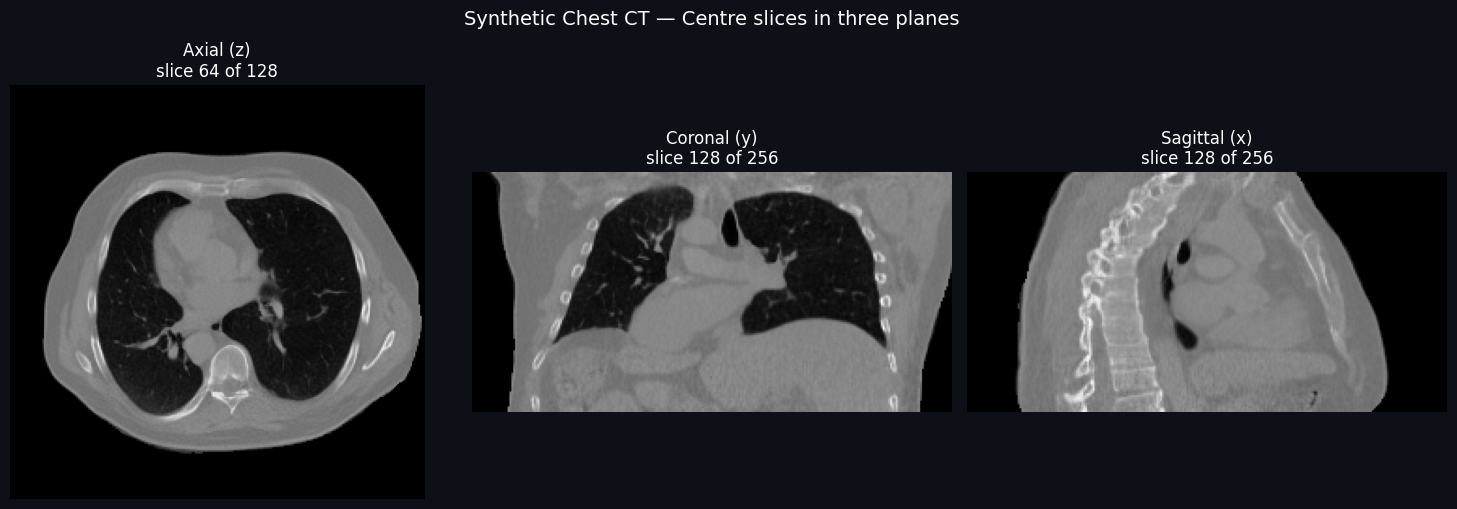

Saved → figures/tut01_three_planes.png


In [3]:
# ── Display the three anatomical planes ───────────────────────────────────
#
# In radiology, every 3D scan is viewed in three standard planes:
#   Axial    = horizontal slice  (seen from below, like looking up at the feet)
#   Coronal  = front-to-back slice (seen from the front)
#   Sagittal = left-right slice   (seen from the side)

cx, cy, cz = [s // 2 for s in data.shape]   # centre slice indices

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

planes = [
    ('Axial (z)',    np.rot90(data[:, :, cz]),   f'slice {cz} of {data.shape[2]}'),
    ('Coronal (y)',  np.rot90(data[:, cy, :]),   f'slice {cy} of {data.shape[1]}'),
    ('Sagittal (x)', np.rot90(data[cx, :, :]),  f'slice {cx} of {data.shape[0]}'),
]

for ax, (name, slc, subtitle) in zip(axes, planes):
    ax.imshow(slc, cmap='gray', vmin=-1000, vmax=1000, aspect='equal')
    ax.set_title(f'{name}\n{subtitle}', fontsize=12)
    ax.axis('off')

fig.suptitle('Synthetic Chest CT — Centre slices in three planes', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures/tut01_three_planes.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved → figures/tut01_three_planes.png')

### What are you looking at?

In the **axial slice** (top-down view of the chest):
- The bright white ring on the outside = **ribs** (bone, high HU)
- Dark regions = **lung tissue** (mostly air, very low HU)
- Central grey oval = **heart** (soft tissue)
- Thin bright oval in the middle = **spine** (bone)

In the **coronal slice** (front view):
- You can see the left and right lung fields
- The bright spine runs vertically in the centre

In the **sagittal slice** (side view):
- The heart appears as a rounded grey structure
- You can trace the trachea (dark tube) running down toward the lungs

---

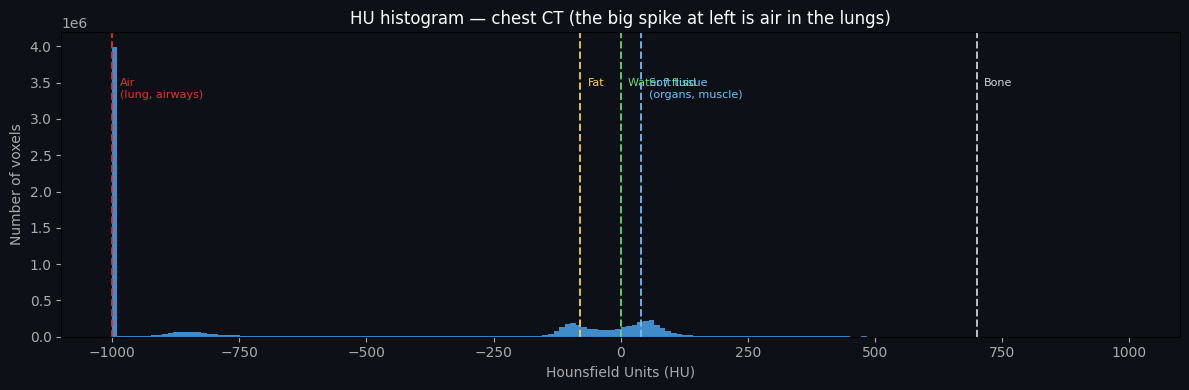

Most voxels are air (lungs). Soft tissue makes up a smaller share.


In [4]:
# ── HU value histogram — the 'fingerprint' of the scan ────────────────────
#
# Instead of looking at one slice, let's look at ALL the voxels at once.
# A histogram shows how many voxels have each HU value.

flat = data.ravel()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(flat, bins=200, range=(-1100, 1100), color='#4dabf7', alpha=0.8, edgecolor='none')

# Annotate the tissue regions
annotations = [
    (-1000, '#e03131', 'Air\n(lung, airways)'),
    (-80,   '#ffd43b', 'Fat'),
    (0,     '#69db7c', 'Water / fluid'),
    (40,    '#74c0fc', 'Soft tissue\n(organs, muscle)'),
    (700,   '#ced4da', 'Bone'),
]
for hu, color, label in annotations:
    ax.axvline(hu, color=color, linestyle='--', linewidth=1.4, alpha=0.9)
    ax.text(hu + 15, ax.get_ylim()[1] * 0.85, label, color=color, fontsize=8, va='top')

ax.set_xlabel('Hounsfield Units (HU)')
ax.set_ylabel('Number of voxels')
ax.set_title('HU histogram — chest CT (the big spike at left is air in the lungs)')
ax.set_xlim(-1100, 1100)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures/tut01_hu_histogram.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Most voxels are air (lungs). Soft tissue makes up a smaller share.')

### Reading the histogram

The large spike on the far left (around −1000 HU) is **air**. In a chest CT, the lungs are mostly air, so this is by far the biggest group of voxels.

The smaller hump around 0–100 HU is **soft tissue** — the heart, chest wall muscles, and organs.

The small bump near +700 HU is **bone** — the ribs, spine, and sternum.

If you ran this on an abdomen CT, the air peak would be much smaller (abdomen has far less air) and the soft tissue hump would be much bigger. Different anatomies have **different HU fingerprints**.

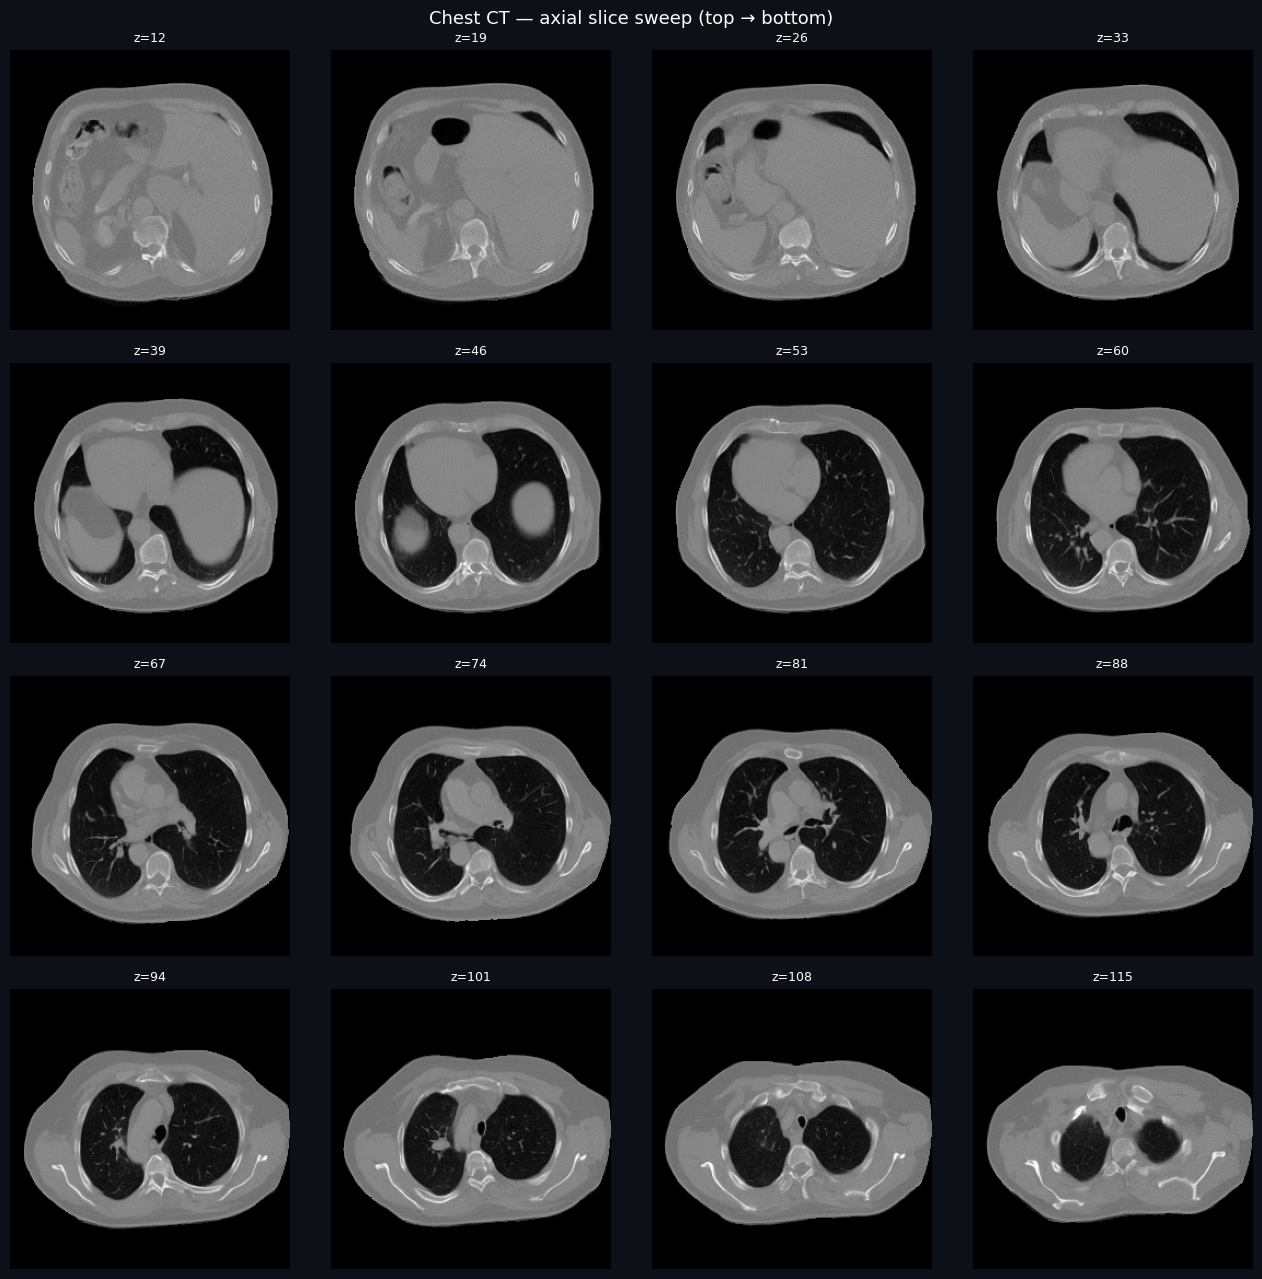

As you sweep from top to bottom you pass through: shoulders → lungs/heart → lower chest.


: 

In [ ]:
# ── A grid of axial slices — seeing the whole volume ──────────────────────
#
# One slice is never enough. Here we sample 16 evenly-spaced axial slices
# from top to bottom of the chest.

n_slices = 16
indices = np.linspace(data.shape[2] // 10, data.shape[2] - data.shape[2] // 10 - 1, n_slices)
indices = [int(round(i)) for i in indices]

fig, axes = plt.subplots(4, 4, figsize=(13, 13))
for ax, z in zip(axes.ravel(), indices):
    ax.imshow(np.rot90(data[:, :, z]), cmap='gray', vmin=-1000, vmax=1000, aspect='equal')
    ax.set_title(f'z={z}', fontsize=9, color='white')
    ax.axis('off')

fig.suptitle('Chest CT — axial slice sweep (top → bottom)', fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures/tut01_axial_sweep.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('As you sweep from top to bottom you pass through: shoulders → lungs/heart → lower chest.')

## Summary

| Concept | Key takeaway |
|---|---|
| CT voxel value | A Hounsfield Unit (HU) — physically calibrated |
| Air | −1000 HU, black |
| Soft tissue | ~40 HU, grey |
| Bone | ~700 HU, white |
| Three planes | Axial, coronal, sagittal — always view all three |
| NIfTI shape | (X, Y, Z) voxel dimensions |
| Spacing | mm per voxel — needed to compute real distances |

## What's next?

| Notebook | What you will learn |
|---|---|
| **02_ct_windows_and_tissues** | Why the same CT looks completely different with different display settings |
| **03_ct_segmentation_masks** | How AI models label individual organs and tumors in CT |
| **04_brain_mri_contrasts** | How MRI differs from CT, and why the same brain looks different in T1 vs T2 |